# Alignment Sandbox

Notebook for running the Milestone 1 offline-DTW benchmark pipeline on local Mazurka data.

The benchmark now uses directed `reference__query` cases. The reference is the stored template performance, the query is the simulated live performance, and the beat-based metrics score how accurately the alignment predicts reference time from query time.

In [17]:
import importlib
from pathlib import Path
import sys
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "scripts").exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts import config, data_io, evaluation, visualization

config = importlib.reload(config)
data_io = importlib.reload(data_io)
evaluation = importlib.reload(evaluation)
visualization = importlib.reload(visualization)

## 1. Discover Local Data

The loader supports a manifest, the split Mazurka layout under `data/raw/wav_22050_mono/` and `data/raw/annotations_beat/`, or an inferred directory layout. `build_recording_pairs(...)` now returns directed benchmark cases, so `A__B` and `B__A` are both present.

In [18]:
recordings = data_io.discover_recordings(config.RAW_DATA_DIR)
pairs = data_io.build_recording_pairs(recordings)
small_pairs = evaluation.select_recording_pairs(pairs, selection_mode="small") if pairs else []
len(recordings), len(pairs), len(small_pairs)

(301, 19392, 6)

## 2. Inspect the Preview Benchmark Case

The preview case is the fastest directed case inside the fixed `small` benchmark. `small` is a 3-recording preview set from the shortest eligible piece, which expands to 6 directed cases total.

In [19]:
if pairs:
    preview_pair = evaluation.select_preview_recording_pair(pairs)
    display({
        "piece": preview_pair.piece,
        "preview_pair_id": preview_pair.pair_id,
        "reference_recording": preview_pair.reference.recording_id,
        "query_recording": preview_pair.query.recording_id,
        "small_benchmark_case_ids": [pair.pair_id for pair in small_pairs],
    })
else:
    print("No local benchmark cases found. Add data under data/raw/ first.")

{'piece': 'Chopin_Op030No2',
 'preview_pair_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'reference_recording': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
 'query_recording': 'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'small_benchmark_case_ids': ['Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
  'Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
  'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15__Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
  'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15__Chopin_Op030No2_Ashkenazy-1982_pid50848-03',
  'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Ashkenazy-1982_pid50848-03',
  'Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Chopin_Op030No2_Ashkenazy-1981_pid9058-19']}

## 3. Run One Preview Offline DTW Alignment

This runs one directed `reference <- query` alignment and computes beat-based tracking metrics at query beat times.

In [20]:
if pairs:
    preview_pair = evaluation.select_preview_recording_pair(pairs)
    alignment_result, metric_row = evaluation.evaluate_recording_pair(preview_pair)
    display(metric_row)
else:
    print("Skipping alignment because no benchmark cases were discovered.")

{'method_name': 'offline_dtw',
 'reference_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
 'query_id': 'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'num_beats_used': 193,
 'mean_error_s': -0.0002669718374398059,
 'mean_abs_error_s': 0.05999344047325281,
 'median_abs_error_s': 0.021383544217687955,
 'rmse_s': 0.13412475247162797,
 'max_abs_error_s': 1.184217873015875,
 'p95_abs_error_s': 0.25494766213152076,
 'within_50ms': 0.7305699481865285,
 'within_100ms': 0.8393782383419689,
 'within_200ms': 0.9326424870466321,
 'piece': 'Chopin_Op030No2',
 'pair_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'feature_name': 'chroma_stft'}

## 4. Visualize the Alignment Path

The x-axis is reference time and the y-axis is query time. For the live-tracking benchmark, the downstream metric uses this path to predict reference time from the current query time.

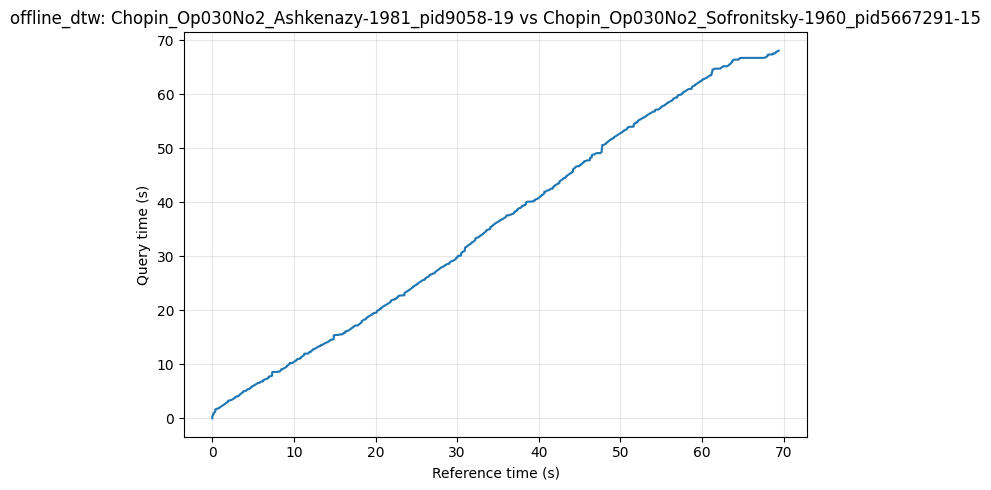

In [21]:
if "alignment_result" in locals():
    visualization.plot_alignment_path(alignment_result)
else:
    print("Run the alignment cell first.")

## 5. Run a Benchmark Mode

Use `single` for one exact directed `pair_id`, `small` for the fixed 3-recording preview benchmark, or `full` for every directed case in the dataset.

In [22]:
if pairs:
    benchmark_mode = "small"  # "single", "small", or "full"
    benchmark_pair_id = None
    if benchmark_mode == "single":
        benchmark_pair_id = evaluation.select_preview_recording_pair(pairs).pair_id

    metrics_frame = evaluation.run_offline_benchmark(
        dataset_root=config.RAW_DATA_DIR,
        output_dir=config.METRICS_DIR,
        experiment_name=f"offline_dtw_notebook_{benchmark_mode}",
        selection_mode=benchmark_mode,
        pair_id=benchmark_pair_id,
        save_outputs=True,
        show_progress=True,
    )
    display(metrics_frame)
else:
    print("No benchmark cases discovered, so the benchmark was skipped.")

offline_dtw_notebook_small:   0%|          | 0/6 [00:00<?, ?it/s]

,method_name,reference_id,query_id,num_beats_used,mean_error_s,mean_abs_error_s,median_abs_error_s,rmse_s,max_abs_error_s,p95_abs_error_s,within_50ms,within_100ms,within_200ms,piece,pair_id,feature_name
0,offline_dtw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,193,-0.000267,0.059993,0.021384,0.134125,1.184218,0.254948,0.730570,0.839378,0.932642,Chopin_Op030No2,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,chroma_stft
1,offline_dtw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,193,-0.001358,0.058787,0.019090,0.132723,1.184218,0.260164,0.756477,0.834197,0.922280,Chopin_Op030No2,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,chroma_stft
2,offline_dtw,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,193,-0.003697,0.059222,0.020136,0.124273,1.024581,0.232798,0.720207,0.818653,0.911917,Chopin_Op030No2,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,chroma_stft
3,offline_dtw,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,193,-0.004319,0.058790,0.018639,0.124713,1.012971,0.230522,0.725389,0.823834,0.911917,Chopin_Op030No2,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,chroma_stft
4,offline_dtw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,193,-0.001234,0.005521,0.004353,0.008078,0.079818,0.007257,0.994819,1.000000,1.000000,Chopin_Op030No2,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,chroma_stft
5,offline_dtw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,193,0.001234,0.005521,0.004353,0.008078,0.079818,0.007257,0.994819,1.000000,1.000000,Chopin_Op030No2,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,chroma_stft


## 6. Plot the Benchmark Summary

/home/diego/School/SP26/E207_project/scripts/visualization.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  figure.tight_layout()


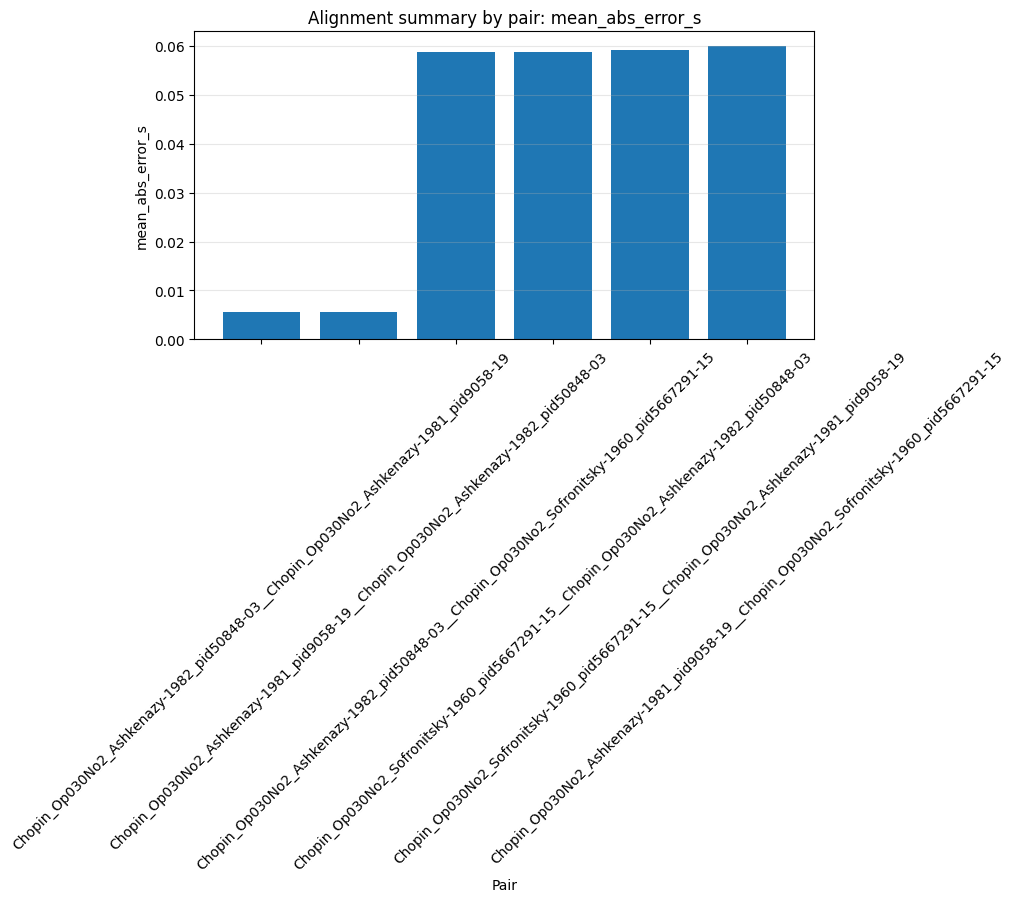

In [23]:
if "metrics_frame" in locals():
    visualization.plot_error_summary(metrics_frame)
else:
    print("Run a benchmark cell first.")